# Implementing micrograd
Micrograd is a tiny autograd engine which implements backpropagation (reverse-mode autodiff) over a dynamically built DAG and a small neural networks libary built on top of it with a Pytorch-like API.

Neural network is a mathematical expression which takes data as an input and weights as an input and the output is a predition of a neural network or loss function.

Backpropagation is more general than neural networks, it can work with many arbitrary mathematical expressions and we happen to use its machinery for training of neural networks.
Backpropagation is an algorithm for computing derivatives (gradients) of complex, differentiable functions by applying the chain rule over a computational graph.

Micrograd works with scalar values, as opposed to real libraries that work with tensors (or vectors or just arrays of scalars).

In [30]:
import math
import numpy as np
import matplotlib.pyplot as plt
from graphviz import Digraph



# Test it:
%matplotlib inline

## Derivative of a simple funciton with one input

In [31]:
def f(x):
    return 3 * x ** 2 - 4 * x + 5

In [32]:
f(3.0)

20.0

In [33]:
xs = np.arange(-5, 5, .25)
print(xs)
ys = f(xs)
print(ys)

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]
[100.      91.6875  83.75    76.1875  69.      62.1875  55.75    49.6875
  44.      38.6875  33.75    29.1875  25.      21.1875  17.75    14.6875
  12.       9.6875   7.75     6.1875   5.       4.1875   3.75     3.6875
   4.       4.6875   5.75     7.1875   9.      11.1875  13.75    16.6875
  20.      23.6875  27.75    32.1875  37.      42.1875  47.75    53.6875]


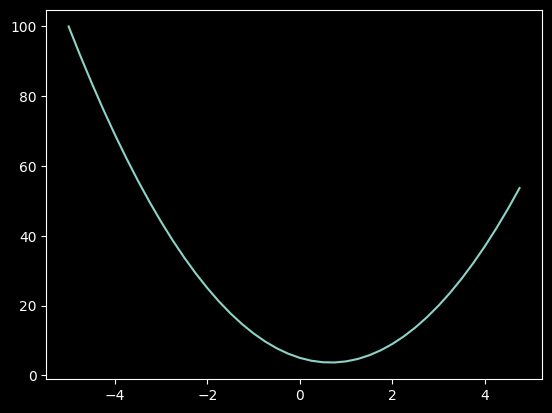

In [34]:
plt.plot(xs, ys);

Derivative in point A (input A) shows us how function will change if we increase input A by tiny amount h, when h is approaching to zero.

L = LIM(h->o) f(A + h) - f(A) / h


In [35]:
def derivative(x):
    h = 0.000001
    return (f(x + h) - f(x)) / h

print(derivative(3))
print(derivative(-3))
print(derivative(7))
print(derivative(2/3))

14.000003002223593
-21.999997002808414
38.000003016236406
2.999378523327323e-06


## Derivative of a function with multiple inputs

In [36]:
a = 2.0
b = -3.0
c = 10.0

d = a * b + c
print(d)

4.0


In [37]:
h = 0.000001
a = 2.0
b = -3.0
c = 10.0

y1 = a * b + c
a += h
y2 = a * b + c

dx_a = (y2 - y1) / h
print("y1", y1)
print("y2", y2)
print("dx_a", dx_a)




y1 4.0
y2 3.9999969999999996
dx_a -3.000000000419334


## Starting the core value object of micrograd and its visualization


In [38]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = '') -> None:
        self.data = data
        self.grad = 0.0 # gradient is the value of a partial derivative of output value in respect to this value
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self) -> str:
        return f"Value(data={self.data}, op={self._op if self._op else 'NOP'} [{self.label}])"

    def __add__(self, other) -> "Value":
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other) -> "Value":
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        def _backward():
            self.grad += 1 - (t ** 2) * out.grad

        out = Value(t, (self, ), _op = 'tanh')
        out._backward = _backward
        return out
    
    def backward(self):
        visited = set()
        ar = []
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                ar.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(ar):
            node._backward()

    

In [39]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10, label="c")
e = a * b
e.label = "e"
d = e + c
d.label = "d"
f = Value(-2, label='f')
L = d * f
L.label = 'L'
print(d)
print(d._prev)
print(d._op)
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0

Value(data=4.0, op=+ [d])
{Value(data=-6.0, op=* [e]), Value(data=10, op=NOP [c])}
+


In [40]:
def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

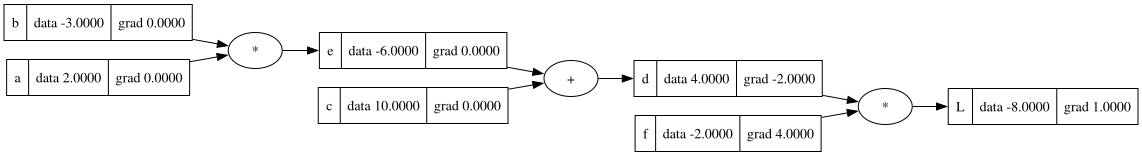

In [41]:
draw_dot(L)

## Manual backprogpagation example #1: simple expression

In [42]:
def local_scope1():
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10, label="c")
    e = a * b
    e.label = "e"
    d = e + c
    d.label = "d"
    f = Value(-2, label='f')
    L = d * f
    L.label = 'L'

    L1 = L.data
    h = 0.0001

    a = Value(2.0 + h, label="a")
    b = Value(-3.0, label="b")
    c = Value(10, label="c")
    e = a * b
    e.label = "e"
    d = e + c
    d.label = "d"
    f = Value(-2, label='f')
    L = d * f
    L.label = 'L'
    L2 = L.data

    print((L2 - L1) / h)
local_scope1()


6.000000000021544


now we want to calculate dL /  dc, first lets calculate dd/dc and dd/de:

dd / dc  = 1.0  
dd / de = 1.0 

(from algebra)

now when we know dL / dd and dd / dc we can calculate dL / dc by using chain rule:

## Chain rule definition

If a variable z depends on the variable y, which itself depends on the variable x( that is, y and z are dependent variables), then z depends on x as well, via the intermediate variable y. In this case, the chain rule is expressed as:

dz/dx = dz/dy * dy/dx

_The chain rule_ is also known as Leibniz's notation.

Intuitively, the chain rule states that knowing the instantaneous rate of change of z relative to y and that of y relative to x allows one to calculate the instantaneous rate of change of z relative of x as the product of the two rates of change.

As put by George Simmons, "If a car travels twice as fast as bicycle and bicycle travels four times as fast as man, then car travels eight times faster (2 x 4) as the man."


so for our example:
dL/dc =  (dL/dd) * (dd/dc)

since both dd/dc and dd/de are 1.0, we can just copy grad value into them from dL/dd


In [43]:
c.grad = d.grad
e.grad = d.grad

# now lets calculate dL/da
# dL / da = (dL / de) * (de / da)

# de / da ?
# since e = a * b, then de/da = b = -3
# so dL/da = -2 * -3 = 6

# by the same logic
#  dL / db = -2 * 2 = -4
a.grad = e.grad * b.data
b.grad = e.grad * a.data

## Manual backpropagation example #2 a neuron
Neuron in neural networks can be represented in a similar fashion to biological neuron, we can say that it has synapses from which it receives inputs from other neurons (inputs are usually represented with x0...xn variables), each synapse only connects to a single neuron ie it can receive input only from a one source, each synapse has an additional weight Wn, which it uses to multiply input (x0 * w0), purpose to have an additional weight is to let every neuron that receives input from the same another neuron to have a personalized coefficient of that input importance.  
Once inputs multiplied by their weights, they all are summed up inside the neuron body and an additional bias is added at the result of the sum. Bias is a way for neural network to have a control over how much "trigger happy" each neuron is.  
Once sum and bias calculated it goes through activation function, activation function is used to normalize and squash values of every neuron. Once value processed through activation function, it goes into output "synapse" which often connected as an input to every other neuron in the next layer of NN.  
Of course there is no real body and no real synapses, values come via variables and result is stored as another variable.

Function that is often used as activation function is sigmoid or tanh (hyperbolic tangent).

tanh x = sinh x / cosh x  

sinh x = (1 - e ** (-2*x)) / 2 * (e ** -x)  
cosh x = (1 + e ** (-2*x)) / 2 * (e ** -x)  

tanh x = (e ** (2*x) - 1) /  (e ** (2 * x) + 1)

(see the method tanh in the Value class)



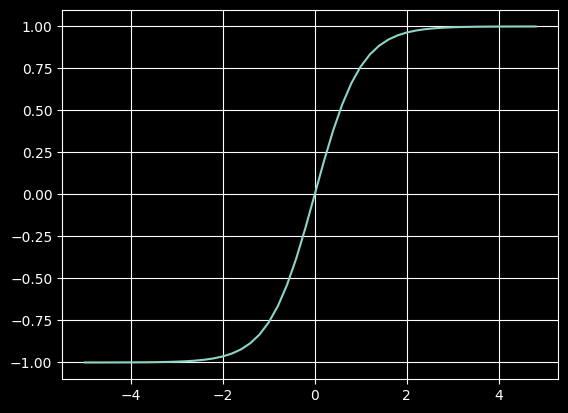

In [44]:
plt.plot(np.arange(-5, 5, .2), np.tanh(np.arange(-5, 5, .2), ))
plt.grid();

In [45]:
# inputs x1 x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1 w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias b
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1;x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
# sum to be fed into activation function n
n = x1w1x2w2 + b;n.label='n'
# output o
o = n.tanh();o.label = 'o'


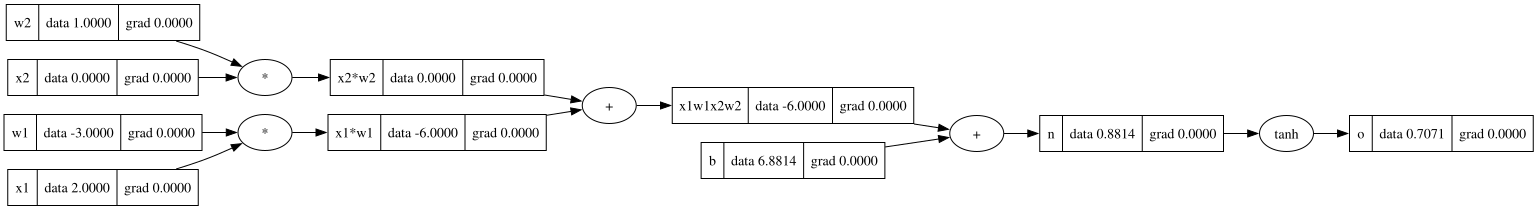

In [46]:
draw_dot(o)

In [47]:
# lets perform manual backpropagation
o.grad = 1.0
# n.grad calculated in the next cell
n.grad = .5
# copy grad from n.grad into every cell that is plus operation
x1w1x2w2.grad = .5
b.grad = .5
x1w1.grad = .5
x2w2.grad = .5

# calc grads for multiply nodes
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad


In [48]:
# o = tanh(n)
# what is do / dn ?
# from calculus: do/dn = 1 - tanh(n) ** 2, since tanh(n) = 0, then: 
# do/dn = 1 - o ** 2
dodn = 1 - o.data ** 2
print(dodn)


0.4999999999999999


## Implementing the backward function for each operation
(see the method _backward in the Value class)

In [49]:
# redefine out neuron:
# inputs x1 x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1 w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias b
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1;x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
# sum to be fed into activation function n
n = x1w1x2w2 + b;n.label='n'
# output o
o = n.tanh();o.label = 'o'

# calc grads using backpropagation
o.grad = 1.0


In [50]:
o._backward()
n._backward()
x1w1x2w2._backward()
b._backward()
x1w1._backward()
x2w2._backward()

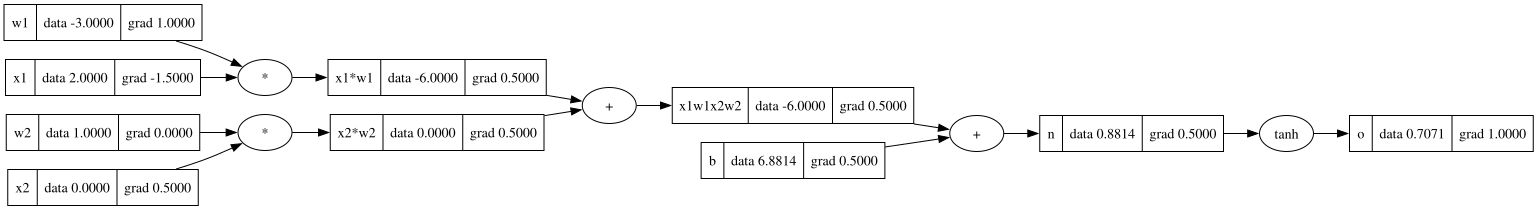

In [51]:
draw_dot(o)

## Implementing the backward function for the whole expression
first we build topologically sorted graph from our expression
see the manual implementation below and the actual method backward in the Value class

In [52]:
def build_topo(node):
    visited = set()
    ar = []
    def helper(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                helper(child)
            ar.append(v)
    helper(node)
    return ar
build_topo(o)


[Value(data=6.881373587019543, op=NOP [b]),
 Value(data=1.0, op=NOP [w2]),
 Value(data=0.0, op=NOP [x2]),
 Value(data=0.0, op=* [x2*w2]),
 Value(data=2.0, op=NOP [x1]),
 Value(data=-3.0, op=NOP [w1]),
 Value(data=-6.0, op=* [x1*w1]),
 Value(data=-6.0, op=+ [x1w1x2w2]),
 Value(data=0.8813735870195432, op=+ [n]),
 Value(data=0.7071067811865476, op=tanh [o])]

In [53]:
# redefine out neuron:
# inputs x1 x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1 w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias b
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1;x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
# sum to be fed into activation function n
n = x1w1x2w2 + b;n.label='n'
# output o
o = n.tanh();o.label = 'o'

# calc grads using backpropagation
o.grad = 1.0
topo = build_topo(o)
for v in reversed(topo):
    print(v.label)
    v._backward()


o
n
x1w1x2w2
x2*w2
x2
w2
x1*w1
x1
w1
b


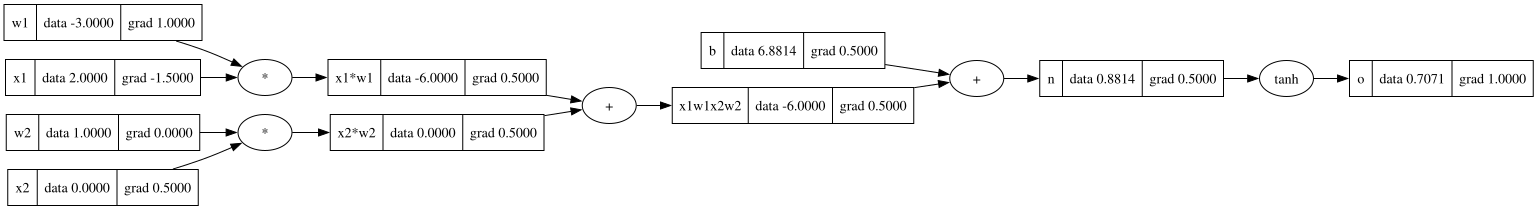

In [54]:
draw_dot(o)

In [55]:
# redefine out neuron:
# inputs x1 x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1 w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias b
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1;x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
# sum to be fed into activation function n
n = x1w1x2w2 + b;n.label='n'
# output o
o = n.tanh();o.label = 'o'

# calc grads using backpropagation
o.backward()

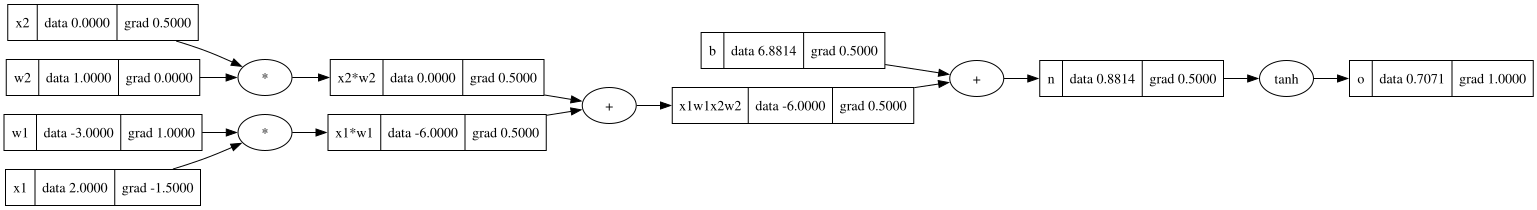

In [56]:
draw_dot(o)

## fixing the backprop bug when one node is used multiple times
to fix the bug, we need to not just set gradient values during backpropagation, but instead accumulate them by using +=, this is in compliance with chain rule for multivariable case

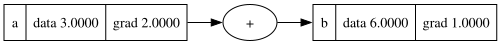

In [57]:
a = Value(3.0, label = 'a')
b = a + a ; b.label = 'b'
b.backward()
draw_dot(b)

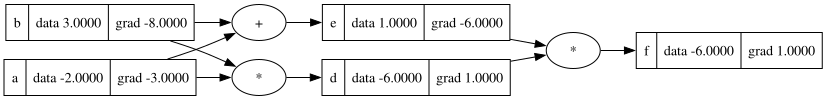

In [58]:
a = Value(-2.0, label = 'a')
b = Value(3.0, label='b')
d = a * b;d.label ='d'
e = a + b;e.label = 'e'
f = d * e;f.label='f'
f.backward()

draw_dot(f)